# РГР 2. Математическая статистика
## Вариант 1

Выполнили студенты Сафин Максим и Фокин Владимир, группа 22.3

## Исходные данные

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Для отображения графиков в ноутбуке
%matplotlib inline

# Настройка отображения pandas
pd.set_option('display.max_rows', 50)
pd.set_option('display.precision', 5)

print("=" * 60)
print("Лабораторная работа: Простая линейная регрессия")
print("Вариант 1")
print("=" * 60)

Лабораторная работа: Простая линейная регрессия
Вариант 1


## 3.1. Загрузка данных

In [2]:
# Загрузка данных из CSV-файла
# Предполагается, что файл 'variant_1_data.csv' находится в той же директории, что и ноутбук

data = pd.read_csv('variant_1_data.csv')

# Проверяем структуру данных
print("\nИнформация о данных:")
print(data.info())

print("\nПервые 5 строк данных:")
print(data.head())

n = len(data)
print(f"\nКоличество наблюдений (n) = {n}")


Информация о данных:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   i       30 non-null     int64  
 1   x       30 non-null     float64
 2   y       30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes
None

Первые 5 строк данных:
   i       x       y
0  1  0.7775  0.7706
1  2  1.3653  2.0631
2  3  2.0717  4.5496
3  4  2.3275  3.4272
4  5  2.3641  2.9128

Количество наблюдений (n) = 30


## 3.2. Диаграмма рассеяния

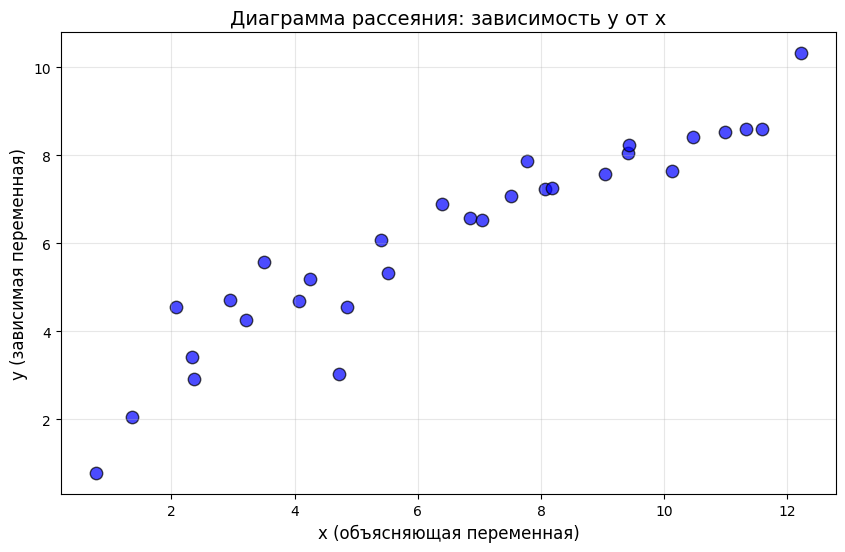

Предварительный вывод: На диаграмме рассеяния наблюдается положительная
линейная зависимость между переменными x и y - с ростом x значения y
в целом увеличиваются, хотя разброс точек заметен.


In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(data['x'], data['y'], alpha=0.7, color='blue', edgecolors='black', s=80)
plt.xlabel('x (объясняющая переменная)', fontsize=12)
plt.ylabel('y (зависимая переменная)', fontsize=12)
plt.title('Диаграмма рассеяния: зависимость y от x', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print("Предварительный вывод: На диаграмме рассеяния наблюдается положительная")
print("линейная зависимость между переменными x и y - с ростом x значения y")
print("в целом увеличиваются, хотя разброс точек заметен.")

## 3.3. Оценивание коэффициентов регрессии

In [4]:
# 4.1. Средние значения
x_bar = np.mean(data['x'])
y_bar = np.mean(data['y'])
print(f"Выборочное среднее x̄ = {x_bar:.6f}")
print(f"Выборочное среднее ȳ = {y_bar:.6f}")

# 4.2. Вспомогательные суммы
S_xx = np.sum((data['x'] - x_bar) ** 2)
S_xy = np.sum((data['x'] - x_bar) * (data['y'] - y_bar))
print(f"\nS_xx = {S_xx:.6f}")
print(f"S_xy = {S_xy:.6f}")

# 4.3. Оценки коэффициентов регрессии
beta_1_hat = S_xy / S_xx
beta_0_hat = y_bar - beta_1_hat * x_bar

print(f"\nОценка коэффициента наклона β̂₁ = {beta_1_hat:.6f}")
print(f"Оценка свободного члена β̂₀ = {beta_0_hat:.6f}")

print("\n" + "=" * 50)
print(f"Полученное уравнение регрессии:")
print(f"ŷ = {beta_0_hat:.6f} + {beta_1_hat:.6f}·x")
print("=" * 50)

Выборочное среднее x̄ = 6.460507
Выборочное среднее ȳ = 6.085180

S_xx = 327.493632
S_xy = 206.729514

Оценка коэффициента наклона β̂₁ = 0.631247
Оценка свободного члена β̂₀ = 2.007002

Полученное уравнение регрессии:
ŷ = 2.007002 + 0.631247·x


## 3.4. Расчёт прогнозных значений и остатков

In [5]:
# Прогнозные значения и остатки
data['y_hat'] = beta_0_hat + beta_1_hat * data['x']
data['e'] = data['y'] - data['y_hat']
data['e_squared'] = data['e'] ** 2

# Таблица с результатами
results_table = data[['i', 'x', 'y', 'y_hat', 'e']].copy()
results_table.index = range(1, n + 1)

print("Таблица: i | x | y | ŷ | e (остатки)")
print("-" * 70)
results_table

Таблица: i | x | y | ŷ | e (остатки)
----------------------------------------------------------------------


,i,x,y,y_hat,e
1,1,0.7775,0.7706,2.49780,-1.72720
2,2,1.3653,2.0631,2.86884,-0.80574
3,3,2.0717,4.5496,3.31476,1.23484
4,4,2.3275,3.4272,3.47623,-0.04903
5,5,2.3641,2.9128,3.49933,-0.58653
6,6,2.9501,4.7224,3.86924,0.85316
7,7,3.2074,4.2667,4.03166,0.23504
8,8,3.5111,5.5796,4.22337,1.35623
9,9,4.0744,4.6881,4.57896,0.10914
10,10,4.2488,5.1874,4.68905,0.49835


In [6]:
# Также выводим в более компактном виде
print("\nРезультаты расчёта (первые 10 наблюдений):")
print(results_table.head(10).to_string())


Результаты расчёта (первые 10 наблюдений):
     i       x       y    y_hat        e
1    1  0.7775  0.7706  2.49780 -1.72720
2    2  1.3653  2.0631  2.86884 -0.80574
3    3  2.0717  4.5496  3.31476  1.23484
4    4  2.3275  3.4272  3.47623 -0.04903
5    5  2.3641  2.9128  3.49933 -0.58653
6    6  2.9501  4.7224  3.86924  0.85316
7    7  3.2074  4.2667  4.03166  0.23504
8    8  3.5111  5.5796  4.22337  1.35623
9    9  4.0744  4.6881  4.57896  0.10914
10  10  4.2488  5.1874  4.68905  0.49835


## 3.5. Оценка дисперсии ошибки

In [7]:
# 4.5. Остаточная сумма квадратов (RSS)
RSS = np.sum(data['e_squared'])
print(f"Остаточная сумма квадратов RSS = {RSS:.6f}")

# 4.6. Оценка дисперсии случайной ошибки
s_squared = RSS / (n - 2)  # несмещённая оценка
s = np.sqrt(s_squared)

print(f"\nОценка дисперсии случайной ошибки s² = {s_squared:.6f}")
print(f"Остаточное стандартное отклонение s = {s:.6f}")

Остаточная сумма квадратов RSS = 16.777049

Оценка дисперсии случайной ошибки s² = 0.599180
Остаточное стандартное отклонение s = 0.774067


## 3.6. Доверительные интервалы для коэффициентов

In [8]:
# 4.7. Стандартные ошибки коэффициентов
SE_beta_1 = s / np.sqrt(S_xx)
SE_beta_0 = s * np.sqrt(1 / n + (x_bar ** 2) / S_xx)

print(f"Стандартная ошибка SE(β̂₁) = {SE_beta_1:.6f}")
print(f"Стандартная ошибка SE(β̂₀) = {SE_beta_0:.6f}")

# 4.8. Критическое значение t-распределения
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, df=n - 2)
print(f"\nКритическое значение t({n - 2}, {alpha / 2}) = {t_crit:.6f}")

# Доверительные интервалы
CI_beta_1_lower = beta_1_hat - t_crit * SE_beta_1
CI_beta_1_upper = beta_1_hat + t_crit * SE_beta_1

CI_beta_0_lower = beta_0_hat - t_crit * SE_beta_0
CI_beta_0_upper = beta_0_hat + t_crit * SE_beta_0

print("\n" + "=" * 60)
print("95% ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ДЛЯ КОЭФФИЦИЕНТОВ")
print("=" * 60)
print(f"\nДля β₀ (свободный член):")
print(f"  [{CI_beta_0_lower:.6f}; {CI_beta_0_upper:.6f}]")
print(f"\nДля β₁ (коэффициент наклона):")
print(f"  [{CI_beta_1_lower:.6f}; {CI_beta_1_upper:.6f}]")

print("\n" + "-" * 60)
if CI_beta_1_lower < 0 < CI_beta_1_upper:
    print("ВЫВОД: Доверительный интервал для β₁ СОДЕРЖИТ ноль,")
    print("        линейная зависимость НЕ является статистически значимой на уровне 5%.")
else:
    print("ВЫВОД: Доверительный интервал для β₁ НЕ СОДЕРЖИТ ноль,")
    print("        линейная зависимость является статистически значимой на уровне 5%.")
print("-" * 60)

Стандартная ошибка SE(β̂₁) = 0.042774
Стандартная ошибка SE(β̂₀) = 0.310381

Критическое значение t(28, 0.025) = 2.048407

95% ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ДЛЯ КОЭФФИЦИЕНТОВ

Для β₀ (свободный член):
  [1.371215; 2.642789]

Для β₁ (коэффициент наклона):
  [0.543629; 0.718865]

------------------------------------------------------------
ВЫВОД: Доверительный интервал для β₁ НЕ СОДЕРЖИТ ноль,
        линейная зависимость является статистически значимой на уровне 5%.
------------------------------------------------------------


## 3.7. Доверительный интервал для функции регрессии

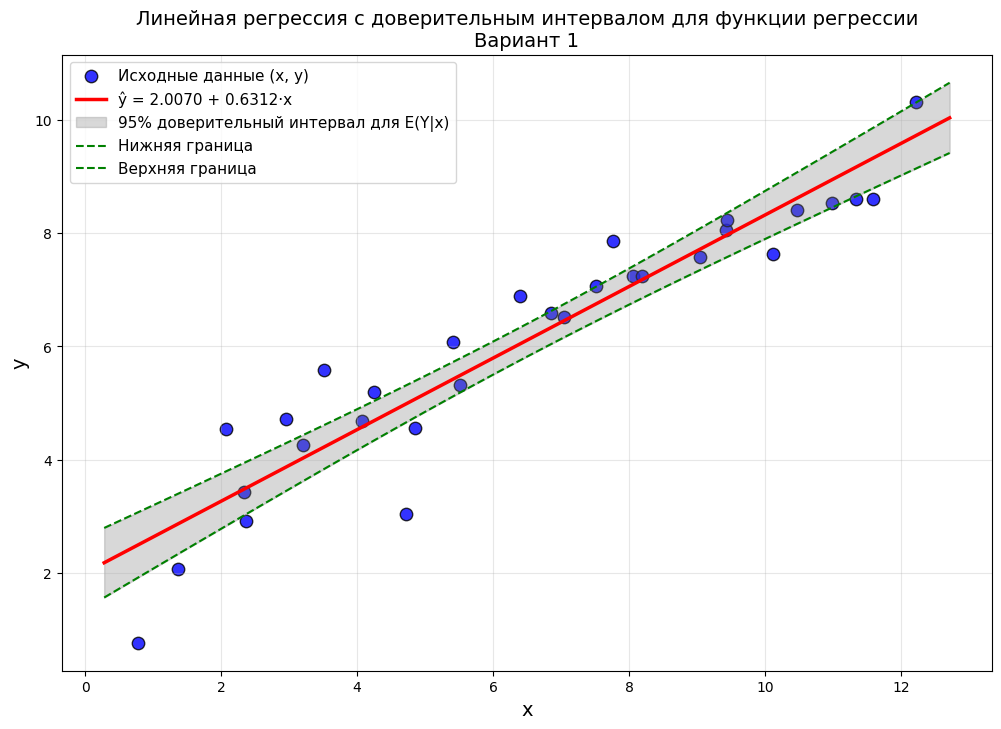

In [9]:
# 4.9. Доверительный интервал для функции регрессии
# Создаем набор значений x0 на всём диапазоне
x_min = data['x'].min()
x_max = data['x'].max()
x_grid = np.linspace(x_min - 0.5, x_max + 0.5, 100)

# Для каждой точки вычисляем доверительный интервал
y_hat_grid = beta_0_hat + beta_1_hat * x_grid
SE_y_hat = s * np.sqrt(1 / n + (x_grid - x_bar) ** 2 / S_xx)

CI_lower = y_hat_grid - t_crit * SE_y_hat
CI_upper = y_hat_grid + t_crit * SE_y_hat

# Построение графика
plt.figure(figsize=(12, 8))

# 1. Исходные точки
plt.scatter(data['x'], data['y'], alpha=0.8, color='blue',
            edgecolors='black', s=80, label='Исходные данные (x, y)')

# 2. Оценённая прямая регрессии
plt.plot(x_grid, y_hat_grid, color='red', linewidth=2.5,
         label=f'ŷ = {beta_0_hat:.4f} + {beta_1_hat:.4f}·x')

# 3-4. Границы доверительного интервала
plt.fill_between(x_grid, CI_lower, CI_upper, color='gray', alpha=0.3,
                 label='95% доверительный интервал для E(Y|x)')
plt.plot(x_grid, CI_lower, color='green', linestyle='--', linewidth=1.5,
         label='Нижняя граница')
plt.plot(x_grid, CI_upper, color='green', linestyle='--', linewidth=1.5,
         label='Верхняя граница')

plt.xlabel('x', fontsize=14)
plt.ylabel('y', fontsize=14)
plt.title('Линейная регрессия с доверительным интервалом для функции регрессии\nВариант 1',
          fontsize=14)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()